In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
X = dataset.iloc[:,[3,4]].values

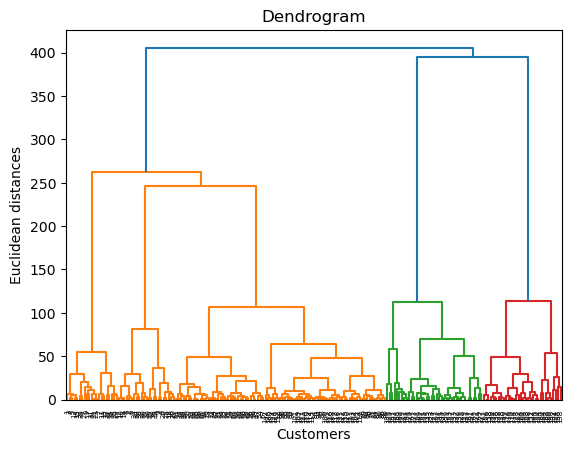

In [4]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram (sch.linkage(X, method = 'ward'))
plt.title("Dendrogram")
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [13]:
from sklearn.cluster import SpectralClustering
clusmodel=SpectralClustering(n_clusters=5)
label=clusmodel.fit_predict(X)

C:\Users\kavvi\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:455: UserWarning: Exited at iteration 626 with accuracies 
[3.70854384e-14 1.77707815e-06 3.42407908e-06 7.84005756e-06
 8.91161604e-06 2.74343268e-06]
not reaching the requested tolerance 2.9802322387695312e-06.
Use iteration 603 instead with accuracy 
2.93886158987644e-06.

  _, diffusion_map = lobpcg(
C:\Users\kavvi\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[1.31645268e-14 1.72063874e-06 2.92201517e-06 5.68162737e-06
 1.83835430e-06 5.47053341e-06]
not reaching the requested tolerance 2.9802322387695312e-06.
  _, diffusion_map = lobpcg(
C:\Users\kavvi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [14]:
supervised = pd.DataFrame(dataset)
supervised ['Cluster_Group'] = label
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_Group
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,4
3,4,Female,23,16,77,4
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,4
196,197,Female,45,126,28,3
197,198,Male,32,126,74,4
198,199,Male,32,137,18,1


C:\Users\kavvi\anaconda3\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


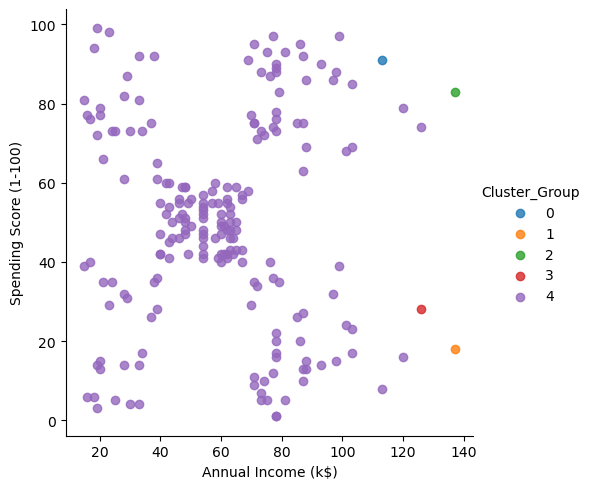

In [15]:
import seaborn as sns
facet = sns.lmplot(data=supervised,x=supervised.columns[3],y=supervised.columns[4], hue=supervised.columns[5],
                  fit_reg=False,legend=True,legend_out=True)